  # Task 1 
### Dataset understanding


In [167]:
import pandas as pd
#Load the dataset
df = pd.read_csv(r"C:\Users\USER\OneDrive\Documents\Data analysis\1st Intership Project\OnlineRetail.csv", parse_dates=["InvoiceDate"],\
                 encoding='latin-1')
    
df.head(10) # firts 10 rows



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [17]:
import pandas as pd

df = pd.read_csv(r"C:\Users\USER\OneDrive\Documents\Data analysis\1st Intership Project\OnlineRetail.csv", parse_dates=["InvoiceDate"],\
                 encoding='latin-1')
df.info() # number of columns and rows, formats...
    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [42]:
import pandas as pd

df = pd.read_csv(r"C:\Users\USER\OneDrive\Documents\Data analysis\1st Intership Project\OnlineRetail.csv", parse_dates=["InvoiceDate"],\
                 encoding='latin-1', parse_dates=["InvoiceDate"])

df[["Quantity","UnitPrice"]].describe() # Numericals features

2.08


,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


The dataset is made of 8 columns and 541909 rows, containing some key informations about transactions for an online store
such that : **InvoiceDate**, **Unitprice**, **Description** of the product that has been sold and the **CustomerID**.
A quick Overview of the set shows some inconsistencies in the data.
The next step of our analysis is then dedicated to the cleaning task, in order for us to ensure the consistency of the data

  # Task 2
### Data Cleaning

- Missing Values

In [23]:
import pandas as pd

df = pd.read_csv(r"C:\Users\USER\OneDrive\Documents\Data analysis\1st Intership Project\OnlineRetail.csv", parse_dates=["InvoiceDate"],\
                 encoding='latin-1')

#Number of missing values per columns
df.isnull().sum()    

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

It appears that only **Description** and **CustomerID** contain missing values, respectively **1454** and **135080**.

In order to not affect the reliability of our analysis since the number of missing values in CustomerID is large enough, instead of just
delete those lines, we will assign them the "Unknown" value

In [101]:
import pandas as pd

df = pd.read_csv(r"C:\Users\USER\OneDrive\Documents\Data analysis\1st Intership Project\OnlineRetail.csv", parse_dates=["InvoiceDate"],\
                 encoding='latin-1')

#replace the missing values by "Unknown"
df["CustomerID"] = df["CustomerID"].fillna("Unknown")

# Drop missing values in Description
df.dropna(subset="Description",inplace=True)   

df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

- Duplicated rows

In [104]:
import pandas as pd

df = pd.read_csv(r"C:\Users\USER\OneDrive\Documents\Data analysis\1st Intership Project\OnlineRetail.csv", parse_dates=["InvoiceDate"],\
                 encoding='latin-1')

#replace the missing values by "Unknown"
df["CustomerID"] = df["CustomerID"].fillna("Unknown")

# Drop missing values in Description
df.dropna(subset="Description",inplace=True)   

#number of duplicated rows
print(f"The number of duplicated rows is : {df.duplicated(keep=False).sum()}")

#Drop of the duplicated rows
df.drop_duplicates(inplace=True)
df.info()



The number of duplicated rows is : 10147
<class 'pandas.core.frame.DataFrame'>
Index: 535187 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    535187 non-null  object        
 1   StockCode    535187 non-null  object        
 2   Description  535187 non-null  object        
 3   Quantity     535187 non-null  int64         
 4   InvoiceDate  535187 non-null  datetime64[ns]
 5   UnitPrice    535187 non-null  float64       
 6   CustomerID   535187 non-null  object        
 7   Country      535187 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 36.7+ MB


- Data Validation

  The overview of the numerical features (Quantity, UnitPrice) previously done, showed the presence of invalid values such as negatives numbers.

  Also, we can observe that the minimun and the maximun values for both columns are far beyond the mean, this suggests the presence of outliers.

  Let us identify and correcting the elements concerned

  

In [164]:
import pandas as pd

df = pd.read_csv(r"C:\Users\USER\OneDrive\Documents\Data analysis\1st Intership Project\OnlineRetail.csv", parse_dates=["InvoiceDate"],\
                 encoding='latin-1')

#replace the missing values by "Unknown"
df["CustomerID"] = df["CustomerID"].fillna("Unknown")

# Drop missing values in Description
df.dropna(subset="Description",inplace=True)   

#Drop of the duplicated rows
df.drop_duplicates(inplace=True)

# Drop rows with invalid Description
df.drop(df[df["Description"].str.contains("wrongly")].index, inplace=True)


To identify the outliers, we will use the **Interquartile Range** (IQR) :
- IQR = 75th - 25th percentile
- Upperbound  = 75th percentile + (1.5 * IQR)
- Lowerbound  = 25th percentile - (1.5 * IQR)

In [151]:
import pandas as pd

df = pd.read_csv(r"C:\Users\USER\OneDrive\Documents\Data analysis\1st Intership Project\OnlineRetail.csv", parse_dates=["InvoiceDate"],\
                 encoding='latin-1')

#replace the missing values by "Unknown"
df["CustomerID"] = df["CustomerID"].fillna("Unknown")

# Drop missing values in Description
df.dropna(subset="Description",inplace=True)   

#Drop the duplicated rows
df.drop_duplicates(inplace=True)

# Drop rows with invalid Description
df.drop(df[df["Description"].str.contains("wrongly")].index, inplace=True)

#for reliability we use only positives quantity values
positive_quantity = df[(df["Quantity"]>0)]

#75th percentile
seventy_fifth = positive_quantity["Quantity"].quantile(0.75)
#25th percentile
twenty_fifth = positive_quantity["Quantity"].quantile(0.25)
#IQR
IQR = seventy_fifth - twenty_fifth

#upper limit
upperbound = seventy_fifth + (1.5*IQR)
#lower limit
lowerbound = twenty_fifth - (1.5*IQR)

#quantity with no outliers
positive_quantity = positive_quantity[(positive_quantity["Quantity"] <= upperbound)]

#median per product Description
median_per_product = positive_quantity.groupby('Description')["Quantity"].median()

#negatives quantity values replaced by the median for each product description 
df.loc[df["Quantity"] < 0, "Quantity"] = df.loc[df["Quantity"] < 0, "Description"]\
      .map(median_per_product)\
      .round()


print(f"The Interquartile Range is {IQR}")
print(upperbound,lowerbound)
print(df[(df["Quantity"] <= upperbound)].shape)



The Interquartile Range is 10.0
26.0 -14.0
(507516, 8)


we apply the same procedure for UnitPrice

In [ ]:

positive_unitprice = df[(df["UnitPrice"]>0)]

#75th percentile
seventy_fifth = positive_unitprice["UnitPrice"].quantile(0.75)
#25th percentile
twenty_fifth = positive_unitprice["UnitPrice"].quantile(0.25)
#IQR
IQR = seventy_fifth - twenty_fifth

#upper limit
upperbound = seventy_fifth + (1.5*IQR)
#lower limit
lowerbound = twenty_fifth - (1.5*IQR)

#unitprice with no outliers
positive_unitprice = positive_unitprice[(positive_unitprice["UnitPrice"] <= upperbound)]

#median per product Description
median_per_product = positive_unitprice.groupby('Description')["UnitPrice"].median()

#negatives unitprice values replaced by the median for each product description 
df.loc[df["UnitPrice"] < 0, "UnitPrice"] = df.loc[df["UnitPrice"] < 0, "Description"]\
      .map(median_per_product)\
      .round()

We reach to the final **cleaned dataset**,

In [168]:
import pandas as pd

df = pd.read_csv(r"C:\Users\USER\OneDrive\Documents\Data analysis\1st Intership Project\OnlineRetail.csv", parse_dates=["InvoiceDate"],\
                 encoding='latin-1')

#replace the missing values by "Unknown" in customerID
df["CustomerID"] = df["CustomerID"].fillna("Unknown")

# Drop missing values in Description
df.dropna(subset="Description",inplace=True)   

#Drop the duplicated rows
df.drop_duplicates(inplace=True)

# Drop rows with invalid Description
df.drop(df[df["Description"].str.contains("wrongly")].index, inplace=True)

#for reliability we use only positives quantity values
positive_quantity = df[(df["Quantity"]>0)]

#75th percentile
seventy_fifth = positive_quantity["Quantity"].quantile(0.75)
#25th percentile
twenty_fifth = positive_quantity["Quantity"].quantile(0.25)
#IQR
IQR = seventy_fifth - twenty_fifth

#upper limit
upperbound = seventy_fifth + (1.5*IQR)
#lower limit
lowerbound = twenty_fifth - (1.5*IQR)

#quantity with no outliers
positive_quantity = positive_quantity[(positive_quantity["Quantity"] <= upperbound)]

#median per product Description
median_per_product = positive_quantity.groupby('Description')["Quantity"].median()

#negatives quantity values replaced by the median for each product description 
df.loc[df["Quantity"] < 0, "Quantity"] = df.loc[df["Quantity"] < 0, "Description"]\
      .map(median_per_product)\
      .round()


positive_unitprice = df[(df["UnitPrice"]>0)]

#75th percentile
seventy_fifths = positive_unitprice["UnitPrice"].quantile(0.75)
#25th percentile
twenty_fifths = positive_unitprice["UnitPrice"].quantile(0.25)
#IQR
IQRs = seventy_fifths - twenty_fifths

#upper limit
upperlimit = seventy_fifths + (1.5*IQRs)
#lower limit
lowerlimit = twenty_fifths - (1.5*IQRs)

#unitprice with no outliers
positive_unitprice = positive_unitprice[(positive_unitprice["UnitPrice"] <= upperlimit)]

#median per product Description
median_per_product = positive_unitprice.groupby('Description')["UnitPrice"].median()

#negatives unitprice values replaced by the median for each product description 
df.loc[df["UnitPrice"] <= 0, "UnitPrice"] = df.loc[df["UnitPrice"] <= 0, "Description"]\
      .map(median_per_product)\
      .round()


cleaned = (df["Quantity"] <= upperbound)&(df["UnitPrice"] <= upperlimit)&(df["UnitPrice"] > 0)

df[["Quantity","UnitPrice"]][cleaned].describe()

#export the cleaned dataset
df[cleaned].to_csv("cleaned_dataset", index=False, encoding='utf-8', header=True)

,Quantity,UnitPrice
count,468238.000000,468238.000000
mean,6.156613,2.602126
std,6.362871,1.929566
min,1.000000,0.001000
25%,1.000000,1.250000
50%,4.000000,2.080000
75%,10.000000,3.750000
max,26.000000,8.330000


**Cleaning summary**

|Issue found | Action taken |
|------------|-----------|
|Missing Value | missing values has been drop in the Description column and replace by "Unknown" in customerID|   
|Duplicated | removed|
|Invalid entries | 13 Invalid entries removed in Description, negatives values in Quantity and UnitPrice has been replaced by the median|
| Outliers | removed |


Total entries in te initial dataset = 541909

After correction = 468238

Rows removed = 73671

  # Task 3 & 4
### Exploratory Data analysis (EDA) and Data Visualization

statistics summary

In [175]:
import pandas as pd

#load the cleaned dataset 
df = pd.read_csv("cleaned_dataset", parse_dates=["InvoiceDate"])

#statistics summary
df.describe() 


,Quantity,InvoiceDate,UnitPrice
count,468238.000000,468238,468238.000000
mean,6.156613,2011-07-05 17:58:38.134452992,2.602126
min,1.000000,2010-12-01 08:26:00,0.001000
25%,1.000000,2011-03-29 11:15:00,1.250000
50%,4.000000,2011-07-21 09:31:00,2.080000
75%,10.000000,2011-10-19 15:26:00,3.750000
max,26.000000,2011-12-09 12:50:00,8.330000
std,6.362871,NaN,1.929566


Best selling products,

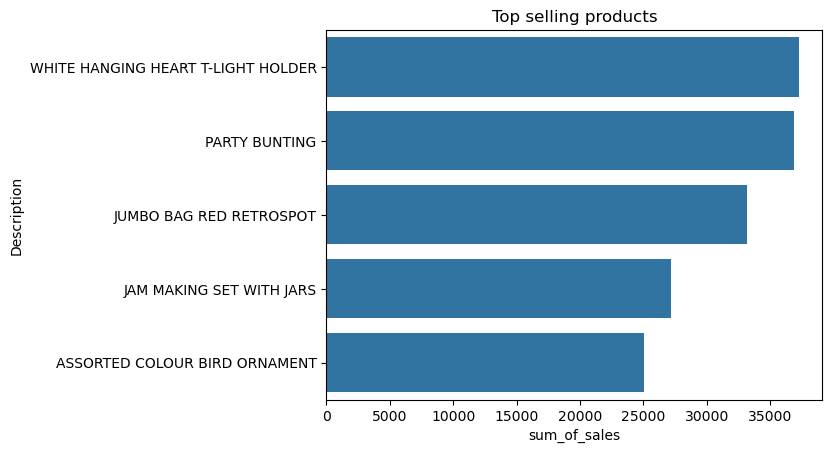

In [201]:
import pandas as pd

#load the cleaned dataset 
df = pd.read_csv("cleaned_dataset", parse_dates=["InvoiceDate"])

#Creation of the column Total_sales
df["Total_sales"] = df["Quantity"]*df["UnitPrice"]

#product sorted by sum_of_sales descending
best_product = df.groupby('Description', as_index=False)\
                                             .agg( 
                                                  Total_quantity = ("Quantity","sum"),
                                                  sum_of_sales = ("Total_sales","sum")
                                                 )\
                                             .sort_values(by="sum_of_sales", ascending=False)\
                                             .head(5)

sns.barplot(x="sum_of_sales", y="Description", data=best_product)
plt.title("Top selling products")
plt.show()

Highest revenue generating countries

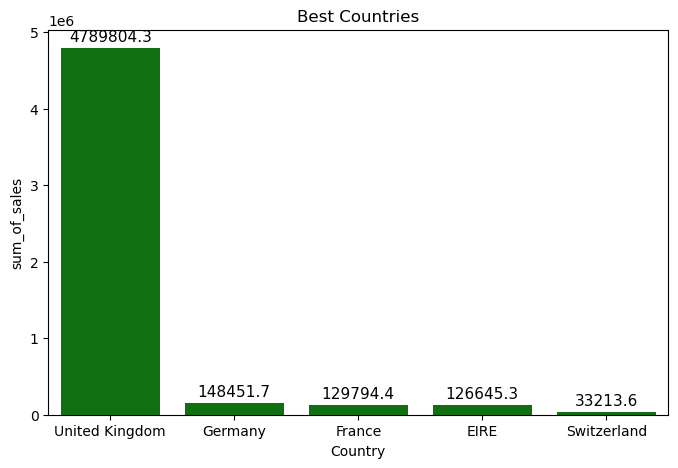

In [232]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

#load the cleaned dataset 
df = pd.read_csv("cleaned_dataset", parse_dates=["InvoiceDate"])

#Creation of the column Total_sales
df["Total_sales"] = df["Quantity"]*df["UnitPrice"]

#country sorted by sum_of_sales descending
best_country = df.groupby('Country', as_index=False)\
                                             .agg( 
                                                  Total_quantity = ("Quantity","sum"),
                                                  sum_of_sales = ("Total_sales","sum")
                                                 )\
                                             .sort_values(by="sum_of_sales", ascending=False)\
                                             .head(5)


plt.figure(figsize=(8,5))
ax = sns.barplot(data=best_country, x="Country", y="sum_of_sales", color="green",errorbar=None)

# Ajouter des valeurs au-dessus de chaque barre
for p in ax.patches:
 ax.annotate(f"{p.get_height():.1f}",
   (p.get_x() + p.get_width() / 2., p.get_height()),
   ha='center', va='center',
   fontsize=11, color='black', xytext=(0, 8),
   textcoords='offset points')
    
plt.title("Best Countries")
plt.show()

Monthly sales trends,

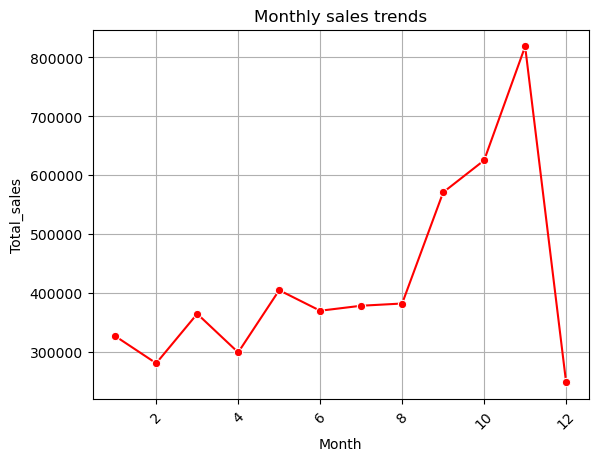

In [233]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

#load the cleaned dataset 
df = pd.read_csv("cleaned_dataset", parse_dates=["InvoiceDate"])

#Creation of the column Total_sales
df["Total_sales"] = df["Quantity"]*df["UnitPrice"]
#création d'une colonne de mois
df["InvoiceMonth"] = df["InvoiceDate"].dt.month

#total des ventes par mois pour l'année 2011
Monthly_trends = df[(df["InvoiceDate"].dt.year) == 2011].groupby('InvoiceMonth', as_index=False)["Total_sales"].sum()


sns.lineplot(x="InvoiceMonth", y="Total_sales", color="red", data=Monthly_trends, marker= 'o')
plt.title("Monthly sales trends")
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.grid(True)
plt.show()



  # Task 5
### Insights

From the Exploratory Data Analysis, 3 keys insigths can be drawn :
- The best selling items are decorative objects or items related to festive events
- An exponential increase in sales between August and November
- United kingdom is the most profitable market